<a href="https://colab.research.google.com/github/sherlyazkiah/PCVK/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import library

In [3]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

3. Manually create a Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO,
TOZERO_INV)

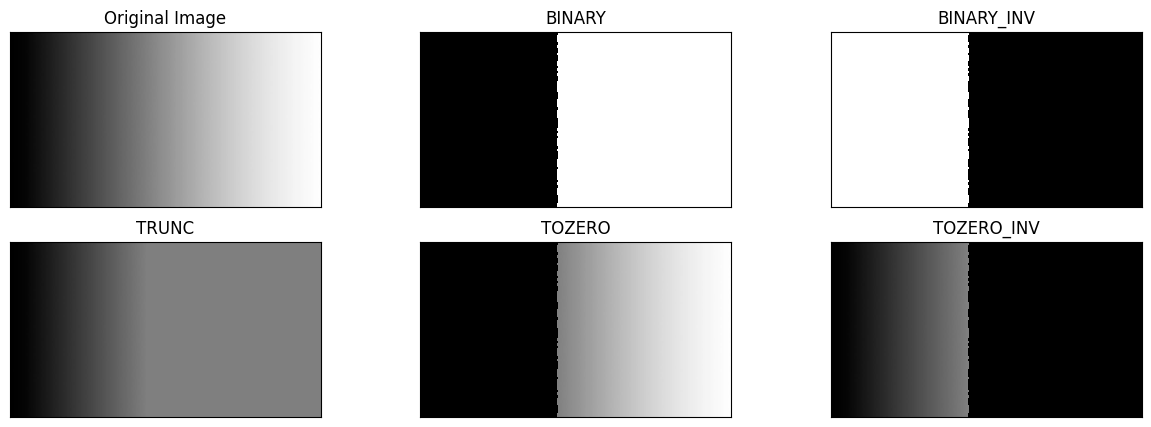

In [ ]:
filename = '/content/drive/MyDrive/PCVK/Images/gradient.jpg'
img = cv.imread(filename)
thresh = 127  # nilai threshold yang ditentukan

# 1. thresh1: jika pixel di img > 127, maka thresh1 bernilai 255 (putih), selain itu 0 (hitam)
ret, thresh1 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY)

# 2. thresh2: binary threshold inverse
ret, thresh2 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY_INV)

# 3. Threshold Truncate
ret, thresh3 = cv.threshold(img, thresh, 255, cv.THRESH_TRUNC)

# 4. Threshold ToZero
ret, thresh4 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO)

# 5. Threshold ToZero Inverse
ret, thresh5 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO_INV)

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], 'gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()


4.	Create Otsu Thresholding without using the library. Also display the threshold value when you use Otsu's, as shown in the following image. (use the image lena_gs_lc2.jpg so that it really looks different between the otsu's results and the usual global threshold).

/tmp/ipython-input-2379434832.py:46: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [0, 256])


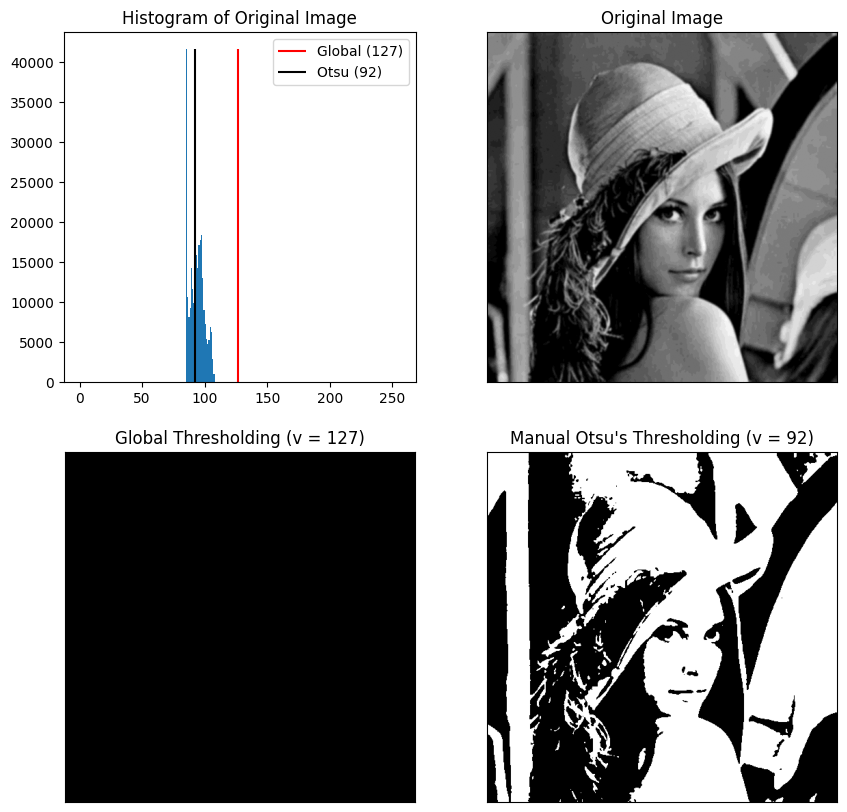

In [31]:
# Load image
filename = '/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg'
img = cv.imread(filename, 0)

# Apply Gaussian Blur to reduce noise
blur = cv.GaussianBlur(img, (5, 5), 0)

# Global Thresholding
thresh = 127
ret, th_global = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)

# Manual Otsu’s Threshold Calculation
hist, bins = np.histogram(blur.ravel(), 256, [0, 256])
total = blur.size
current_max, threshold = 0, 0
sum_total = np.dot(np.arange(256), hist)
sumB, wB, wF = 0, 0, 0

for i in range(256):
    wB += hist[i]
    if wB == 0:
        continue
    wF = total - wB
    if wF == 0:
        break
    sumB += i * hist[i]
    mB = sumB / wB
    mF = (sum_total - sumB) / wF
    between_var = wB * wF * (mB - mF) ** 2
    if between_var > current_max:
        current_max = between_var
        threshold = i

# Apply manual Otsu threshold
_, th_otsu_manual = cv.threshold(blur, threshold, 255, cv.THRESH_BINARY)

# Display results
x = f"Manual Otsu's Thresholding (v = {threshold})"
titles = ['Original Image', 'Global Thresholding (v = 127)', x]
images = [blur, th_global, th_otsu_manual]

plt.figure(figsize=(10, 10))

# Plot histogram with threshold lines
plt.subplot(2, 2, 1)
plt.hist(blur.ravel(), 256, [0, 256])
plt.vlines(thresh, 0, max(hist), colors='red', label='Global (127)')
plt.vlines(threshold, 0, max(hist), colors='black', label=f'Otsu ({threshold})')
plt.legend()
plt.title('Histogram of Original Image')

# Show images
for i in range(len(images)):
    plt.subplot(2, 2, i + 2)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()

5. Create a histogram from a segmented image, the histogram is only in the foreground image. Use the Lily or Leaves image provided in the images folder.

Instructions:

a. You can use cv.calcHist to display a histogram.

b. Open the folloiwng link https://opencvtutorial.
readthedocs.io/en/latest/histogram/histogram.html

c. From the link, note that cv.calcHist has one of the parameters, namely mask. If set to None, the entire image histogram will be counted. If we specify a mask, only the part of the image masked in white will be calculated for the histogram (from the example below it is called Image Segment).

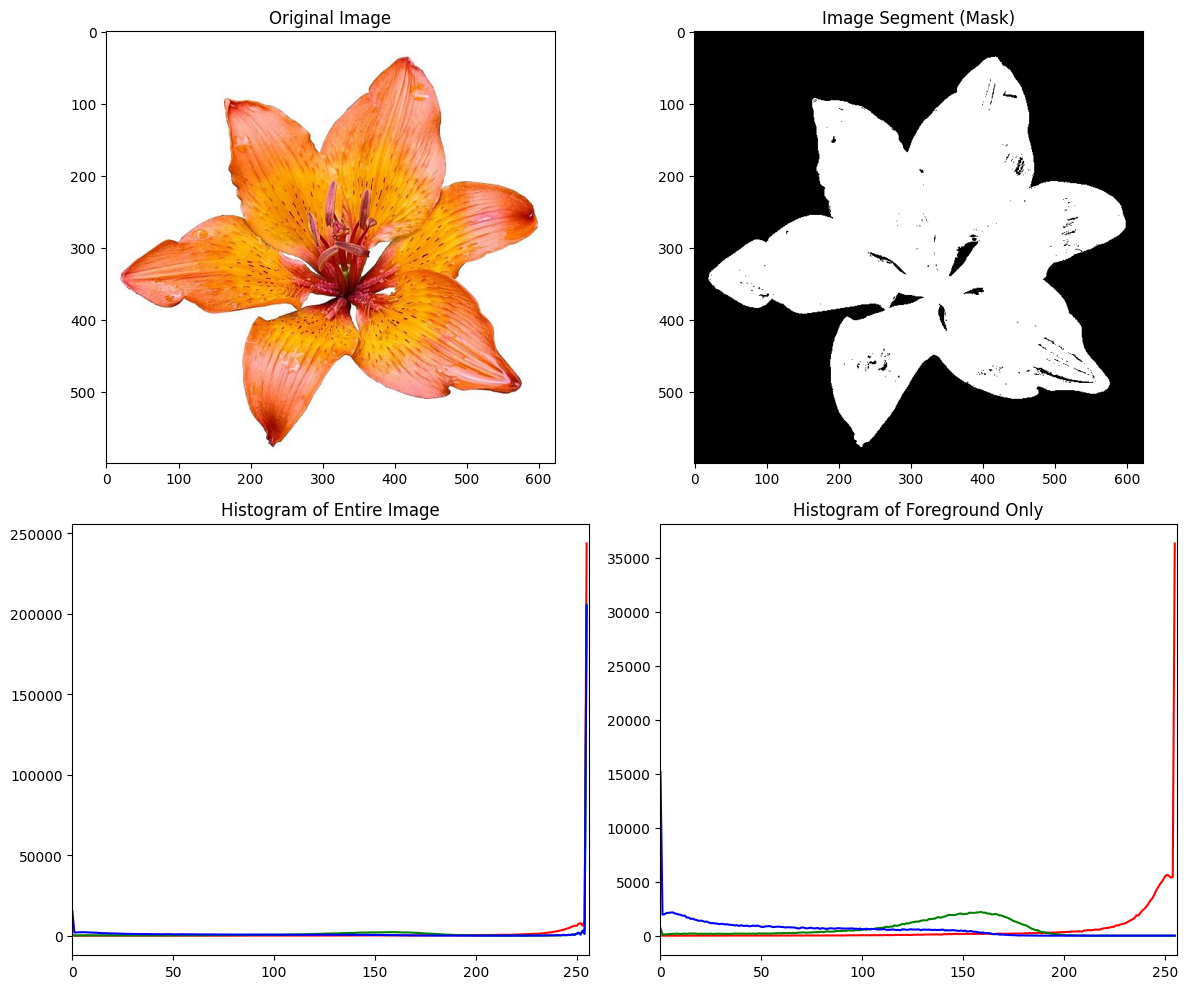

In [11]:
filename = cv.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg')
ori = cv.cvtColor(filename, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(ori, cv.COLOR_BGR2GRAY)

# Apply thresholding (segmentation mask)
_, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Display image
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(ori)
plt.title('Original Image')
plt.axis()

plt.subplot(2, 2, 2)
plt.imshow(mask, 'gray')
plt.title('Image Segment (Mask)')
plt.axis()

# Compute & plot histogram
colors = ('r', 'g', 'b')

plt.subplot(2, 2, 3)
for i, col in enumerate(colors):
    hist_full = cv.calcHist([ori], [i], None, [256], [0, 256])
    plt.plot(hist_full, color=col)
plt.title('Histogram of Entire Image')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
for i, col in enumerate(colors):
    hist_masked = cv.calcHist([ori], [i], mask, [256], [0, 256])
    plt.plot(hist_masked, color=col)
plt.title('Histogram of Foreground Only')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

6. Perform color segmentation on the image "peppers.jpg", display only yellow colors. (Hint: you can use K-Means to display only certain colors)

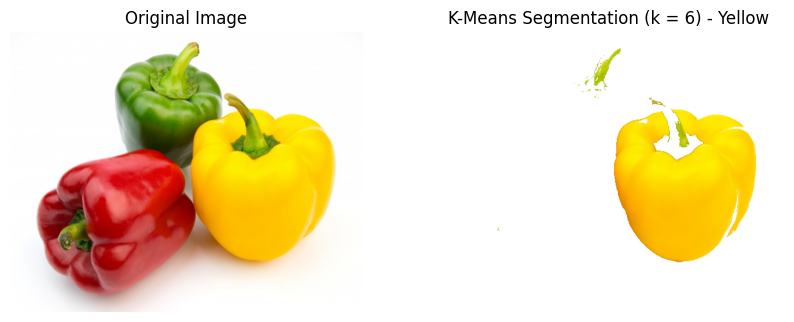

In [24]:
peppers = '/content/drive/MyDrive/PCVK/Images/peppers.jpg'
img = cv.imread(peppers)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert image to 2D array
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Define criteria and number of cluster
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 6

# KMeans clustering
_, labels, centers = cv.kmeans(
    pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS
)

# Convert to integer
centers = np.uint8(centers)

# Flatten array label
labels = labels.flatten()

# Reference yellow color (R=255, G=255, B=0)
yellow_rgb = np.array([255, 255, 0])

# Compute Euclidean distance from each centroid to the reference yellow
distances = np.linalg.norm(centers - yellow_rgb, axis=1)

# Choose cluster closest to pure yellow
yellow_index = np.argmin(distances)

#Create mask for yellow cluster
mask = (labels == yellow_index)
mask = mask.reshape(img_rgb.shape[:2])

# Display only the yellow area
only_yellow = np.ones_like(img_rgb) * 255  # white background
only_yellow[mask] = img_rgb[mask]          # yellow region

# Show result
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(only_yellow)
plt.title(f'K-Means Segmentation (k = {k}) - Yellow')
plt.axis('off')

plt.show()

7. Open the crossword.jpg file. With the knowledge of thresholding that you have learned. Perform binary thresholding with the best results in your opinion. Copy the code and image results in this module.

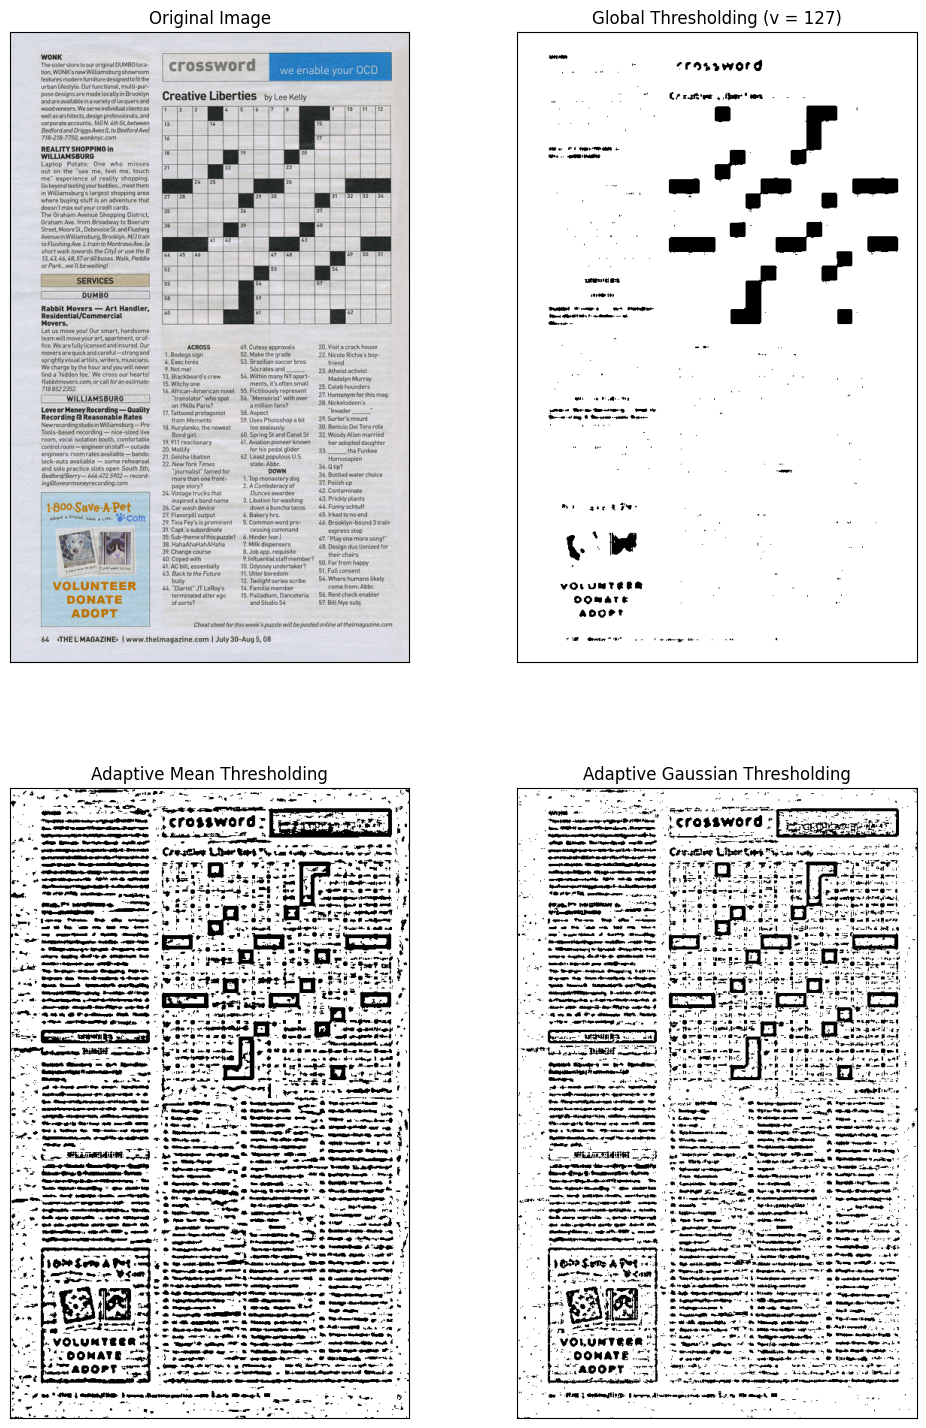

In [30]:
filename = ('/content/drive/MyDrive/PCVK/Images/crossword.jpg')
img = cv.imread(filename, 5)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray = cv.medianBlur(gray, 5)

thresh = 127

ret, th1 = cv.threshold(gray, thresh, 255, cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2)
th3 = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

titles = ['Original Image', 'Global Thresholding (v = 127)', 'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]

plt.figure(figsize=(12, 18))
for i in range(len(images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()